# Fiji Earthquakes — South Pacific Orthographic Projection

In this section we will be mapping with style. The main goal is to produce a high-quality map of high magnitude seismic activity near Fiji.

This section was an inspiration from **Professor AJ Smit**'s [activity](https://tangledbank.netlify.app/BCB744/tasks/BCB744_Task_Bonus.html#question-2) on recreating the Fiji Earthquakes map he made, including only the earthquake data for earthquakes of magnitude greater than the 75th percentile, adding a point for five South Pacific island nations, ensuring the point is correctly associated with the island name, that the map is correctly labelled and has a title.

The map will be reprojected onto an oblique orthographic (3D like) view with bathymetric shading, island nation capitals, and a nice colour palette. Most of the coding in this section follows that of the [Mapping projections]() notebook. 

### Plot options

Before we begin with the coding, let us set sensible notebook defaults up front so that every plot renders at a consistent resolution and aspect ratio. You can ignore this part if you are coding in Base R or RStudio

In [1]:
options(repr.plot.width  = 12, 
        repr.plot.height = 10, 
        repr.plot.res    = 220
        )

### Load libraries and data

We keep imports grouped by purpose so that any future reader immediately knows why each package is present. For anyone who skipped introductory sessions, I will comment on what each package we load does. 

In this section we introduce three new packages: `{ggshadow}`, `{ggtext}` and `{showtext}`.

In [8]:
library(tidyverse)          # Data wrangling & ggplot2
library(sf)                 # Simple-features spatial objects
library(rnaturalearth)      # Medium-resolution country polygons
library(rnaturalearthdata)  # Data companion to rnaturalearth
library(rnaturalearthhires) # High-resolution country polygons (GitHub)
library(terra)              # Raster handling (faster than raster pkg)
library(tidyterra)          # ggplot2 integration for terra SpatRasters
library(ggshadow)           # Glowing / shadow point layers
library(ggtext)             # Markdown-aware plot labels
library(patchwork)          # Composing multi-panel figures
library(scales)             # Colour-scale helpers
library(showtext)           # Custom fonts

In [9]:
# Load a clean Google Font for that premium cartographic feel
font_add_google("Montserrat", "mont")
font_add_google("Playfair Display", "playfair")
showtext_auto()

### Projections

The "3D" look is achieved with an oblique ORTHOGRAPHIC projection, centred on Fiji (lon ≈ 178 °E, lat ≈ −18 °S). So we will define two CRS strings:
- WGS84_CRS — standard lon/lat for reading and transforming raw data
- Ortho_Fiji — the 3D-like projection for the final figure

In [11]:
WGS84_CRS  <- st_crs(4326)
Ortho_Fiji <- st_crs("+proj=ortho +lon_0=178 +lat_0=-20 +x_0=0 +y_0=0 +a=6371000 +b=6371000 +units=m +no_defs")

### World Polygons

We will use the high-resolution layer from `{rnaturalearthhires}` and then re-project it.  When wrapping through the anti-meridian we must first `st_break_antimeridian()` and then transform, otherwise the polygons will shear badly.

In [12]:
WorldHires_Raw <- ne_countries(
  scale       = "large",
  returnclass = "sf"
)

# Split polygons at the antimeridian so they survive the orthographic warp
WorldHires_Sf <- WorldHires_Raw %>%
  st_make_valid() %>%
  st_wrap_dateline(options = c("WRAPDATELINE=YES", "DATELINEOFFSET=180")) %>%
  st_transform(Ortho_Fiji)

Warning message in CPL_wrap_dateline(st_geometry(x), options, quiet):
“GDAL Error 1: IllegalArgumentException: Points of LinearRing do not form a closed linestring”
Warning message in CPL_wrap_dateline(st_geometry(x), options, quiet):
“GDAL Error 1: IllegalArgumentException: Points of LinearRing do not form a closed linestring”


### Graticule

A styled graticule (lon/lat grid) helps anchor the orthographic view.

In [13]:
Graticule_Sf <- st_graticule(
  lat = seq(-90,  90, by = 15),
  lon = seq(-180, 180, by = 15),
  crs = WGS84_CRS
) %>%
  st_transform(Ortho_Fiji)

### Fiji Earthquake Data

The built-in {datasets} object `quakes` contains 1000 seismic events recorded near Fiji since 1964.  Columns: **lat**, **long**, **depth**, **mag**, **stations**. We filter to the 75th-percentile magnitude threshold so that only the strongest events remain — these are the ones that matter most seismically. 

In [14]:
data(quakes) # Dataset found in base R

# Threshold: keep only events in the upper quartile of magnitude
MagThreshold <- quantile(quakes$mag, probs = 0.75)

In [15]:
Quakes_Filtered <- quakes %>%
  filter(mag >= MagThreshold) %>%
  # Convert to sf, then reproject for plotting
  st_as_sf(coords = c("long", "lat"), crs = WGS84_CRS) %>%
  st_transform(Ortho_Fiji) %>%
  # Extract projected XY for easier ggplot2 access later
  mutate(
    ProjX = st_coordinates(.)[, 1],
    ProjY = st_coordinates(.)[, 2]
  )

### South Pacific Island Nations

We add five of our favourite South Pacific sovereign states (I asked the google AI to pick at random lol). We will use capital city coordinates so that the point falls on land and the labels are anchored to a recognisable place name.

In [17]:
IslandNations_Df <- tribble(
  ~Nation,           ~Capital,      ~Longitude,  ~Latitude,
  "Fiji",            "Suva",          178.4419,   -18.1416,
  "Vanuatu",         "Port Vila",     168.3273,   -17.7334,
  "Solomon Islands", "Honiara",       159.9729,    -9.4456,
  "Samoa",           "Apia",         -171.8320,   -13.8314,
  "Tonga",           "Nukuʻalofa",   -175.2166,   -21.1394
)

# Promote to sf and reproject
IslandNations_Sf <- IslandNations_Df %>%
  st_as_sf(coords = c("Longitude", "Latitude"), crs = WGS84_CRS) %>%
  st_transform(Ortho_Fiji) %>%
  mutate(
    ProjX = st_coordinates(.)[, 1],
    ProjY = st_coordinates(.)[, 2]
  )

### Clipping Mask (hemisphere boundary)

In orthographic projections, the visible hemisphere is a circle.  We build a circle mask in projected space so we can clip layers cleanly and draw a nice circular frame.

In [18]:
# Radius of the Earth in metres (matches our +a / +b values above)
EarthRadius_m <- 6371000

HemisphereCircle_Sf <- st_point(c(0, 0)) %>%
  st_sfc(crs = Ortho_Fiji) %>%
  st_buffer(EarthRadius_m * 0.9999)   # Tiny inset avoids edge artefacts

### Colour Palette

Lets build a coherent palette that is inspired by deep-ocean blues and volcanic reds.

In [19]:
PaletteOcean <- c(
  "#03001C", "#0D1B5E", "#0D3B8E", "#1565C0",
  "#1E88E5", "#42A5F5", "#90CAF9", "#BBDEFB"
)

PaletteLand <- "#2D4739"   # Dark moss-green for land masses

ColourGridline   <- "#FFFFFF22"   # Nearly invisible gridlines
ColourFrame      <- "#E0E0E0"
ColourBackground <- "#03001C"     # Deepest ocean — matches palette start

# Earthquake magnitude → colour gradient (hot plasma scale)
PaletteQuake <- c(
  "#FFF176",   # pale yellow — lowest quartile boundary
  "#FFB300",   # amber
  "#FF6F00",   # deep orange
  "#D50000",   # vivid red
  "#880E4F"    # crimson — largest events
)

# Label / annotation colours
ColourText  <- "#ECEFF1"
ColourAccent <- "#F48FB1"   # Soft pink for capitals — contrasts well on a dark background

### Assemble the Map

In [21]:
FijiEarthquakeMap <- ggplot() +

  # Ocean fill
  geom_sf(data = HemisphereCircle_Sf, ill = ColourBackground, colour = NA) +

  # Graticule lines 
  geom_sf(data = Graticule_Sf, colour = ColourGridline, linewidth = 0.25, linetype  = "dotted") +

  # Country polygons
  geom_sf(data = WorldHires_Sf, fill = PaletteLand, colour = "#8BC34A55", linewidth = 0.15) +

  # Earthquake events
  geom_point(data = Quakes_Filtered,
    aes(x = ProjX, y = ProjY, size = mag, colour = mag),
    alpha = 0.15,
    shape = 16
  ) +

  # Earthquake events — solid core 
  geom_point(data  = Quakes_Filtered,
    aes(x = ProjX, y = ProjY, size = mag, colour = mag),
    alpha = 0.75,
    shape = 16
  ) +

  # Island nation capitals — outer ring 
  geom_point(data = IslandNations_Sf,
    aes(x = ProjX, y = ProjY),
    shape  = 21,
    size   = 4,
    colour = ColourAccent,
    fill   = "white",
    stroke = 1.5
  ) +

  # Island nation labels 
  # We manually nudge labels per nation to avoid overlap
  geom_text(data = IslandNations_Sf %>%
      mutate(
        NudgeX = c(  180000,  -250000,  -280000,   100000,   200000),
        NudgeY = c(  180000,   120000,   120000,   180000,  -180000)
      ),
    aes(x = ProjX + NudgeX, y = ProjY + NudgeY,
        label = paste0(Nation, "\n(", Capital, ")")),
    colour   = ColourAccent,
    size     = 3.2,
    family   = "mont",
    fontface = "bold",
    lineheight = 0.85
  ) +

  # Connector segments: capital dot → label
  geom_segment(data = IslandNations_Sf %>%
      mutate(
        NudgeX = c(  180000,  -250000,  -280000,   100000,   200000),
        NudgeY = c(  180000,   120000,   120000,   180000,  -180000)
      ),
    aes(x = ProjX, y = ProjY,
        xend = ProjX + NudgeX * 0.75,
        yend = ProjY + NudgeY * 0.75),
    colour    = ColourAccent,
    linewidth = 0.4,
    linetype  = "dashed",
    alpha     = 0.8
  ) +

  # Hemisphere frame (circle outline)
  geom_sf(data = HemisphereCircle_Sf, fill = NA, colour = ColourFrame, linewidth = 0.8
  ) +

  # Colour & size scales 
  scale_colour_gradientn(
    colours = PaletteQuake,
    name    = "Magnitude",
    guide   = guide_colourbar(
      title.position = "top",
      title.hjust    = 0.5,
      barwidth       = unit(6, "cm"),
      barheight      = unit(0.4, "cm"),
      ticks.colour   = "white",
      frame.colour   = "white"
    )
  ) +

  scale_size_continuous(
    name   = "Magnitude",
    range  = c(0.8, 7),
    guide  = guide_legend(
      title.position = "top",
      title.hjust    = 0.5,
      override.aes   = list(alpha = 0.85, colour = "#FFB300"),
      label.theme    = element_text(colour = ColourText, size = 8)
    )
  ) +

  # Coordinate system 
  # Constrain the view to the visible hemisphere circle
  coord_sf(
    crs    = Ortho_Fiji,
    xlim   = c(-EarthRadius_m, EarthRadius_m),
    ylim   = c(-EarthRadius_m, EarthRadius_m),
    expand = FALSE
  ) +

  # Titles & captions 
  labs(
    title    = "Seismic Activity Near Fiji",
    subtitle = paste0(
      "Earthquakes exceeding the 75th-percentile magnitude threshold (≥ ",
      MagThreshold, ") · Orthographic projection centred at 178 °E, 20 °S"
    ),
    caption  = paste0(
      "Data: R built-in `quakes` dataset (1964–present) · ",
      "Basemap: Natural Earth (rnaturalearthhires)\n",
      "★ = National capital city · Point size & colour encode earthquake magnitude"
    )
  ) +

  # Theme 
  theme_void() +
  theme(
    # Canvas
    plot.background  = element_rect(fill = "#070B1A", colour = NA),
    panel.background = element_rect(fill = "#070B1A", colour = NA),

    # Titles
    plot.title = element_text(
      family   = "playfair",
      face     = "bold",
      size     = 26,
      colour   = ColourText,
      hjust    = 0.5,
      margin   = margin(t = 16, b = 4)
    ),
    plot.subtitle = element_text(
      family = "mont",
      size   = 10,
      colour = "#90A4AE",
      hjust  = 0.5,
      margin = margin(b = 12)
    ),
    plot.caption = element_text(
      family = "mont",
      size   = 7.5,
      colour = "#546E7A",
      hjust  = 0.5,
      margin = margin(t = 12, b = 10)
    ),

    # Legend
    legend.position   = "bottom",
    legend.direction  = "horizontal",
    legend.title      = element_text(
      family   = "mont",
      face     = "bold",
      size     = 9,
      colour   = ColourText
    ),
    legend.text       = element_text(
      family = "mont",
      size   = 8,
      colour = ColourText
    ),
    legend.background = element_rect(fill = "#070B1A", colour = NA),
    legend.margin     = margin(t = 6),
    legend.box        = "horizontal",
    legend.spacing.x  = unit(1, "cm"),

    # Outer margins
    plot.margin = margin(10, 20, 10, 20)
  )

Warning message in layer_sf(geom = GeomSf, data = data, mapping = mapping, stat = stat, :
“Ignoring unknown parameters: `ill`”


Yikes! That took forever to write didn't it? Now is the time to find out whether all that time and effort spent writing that whole code chunk paid off.

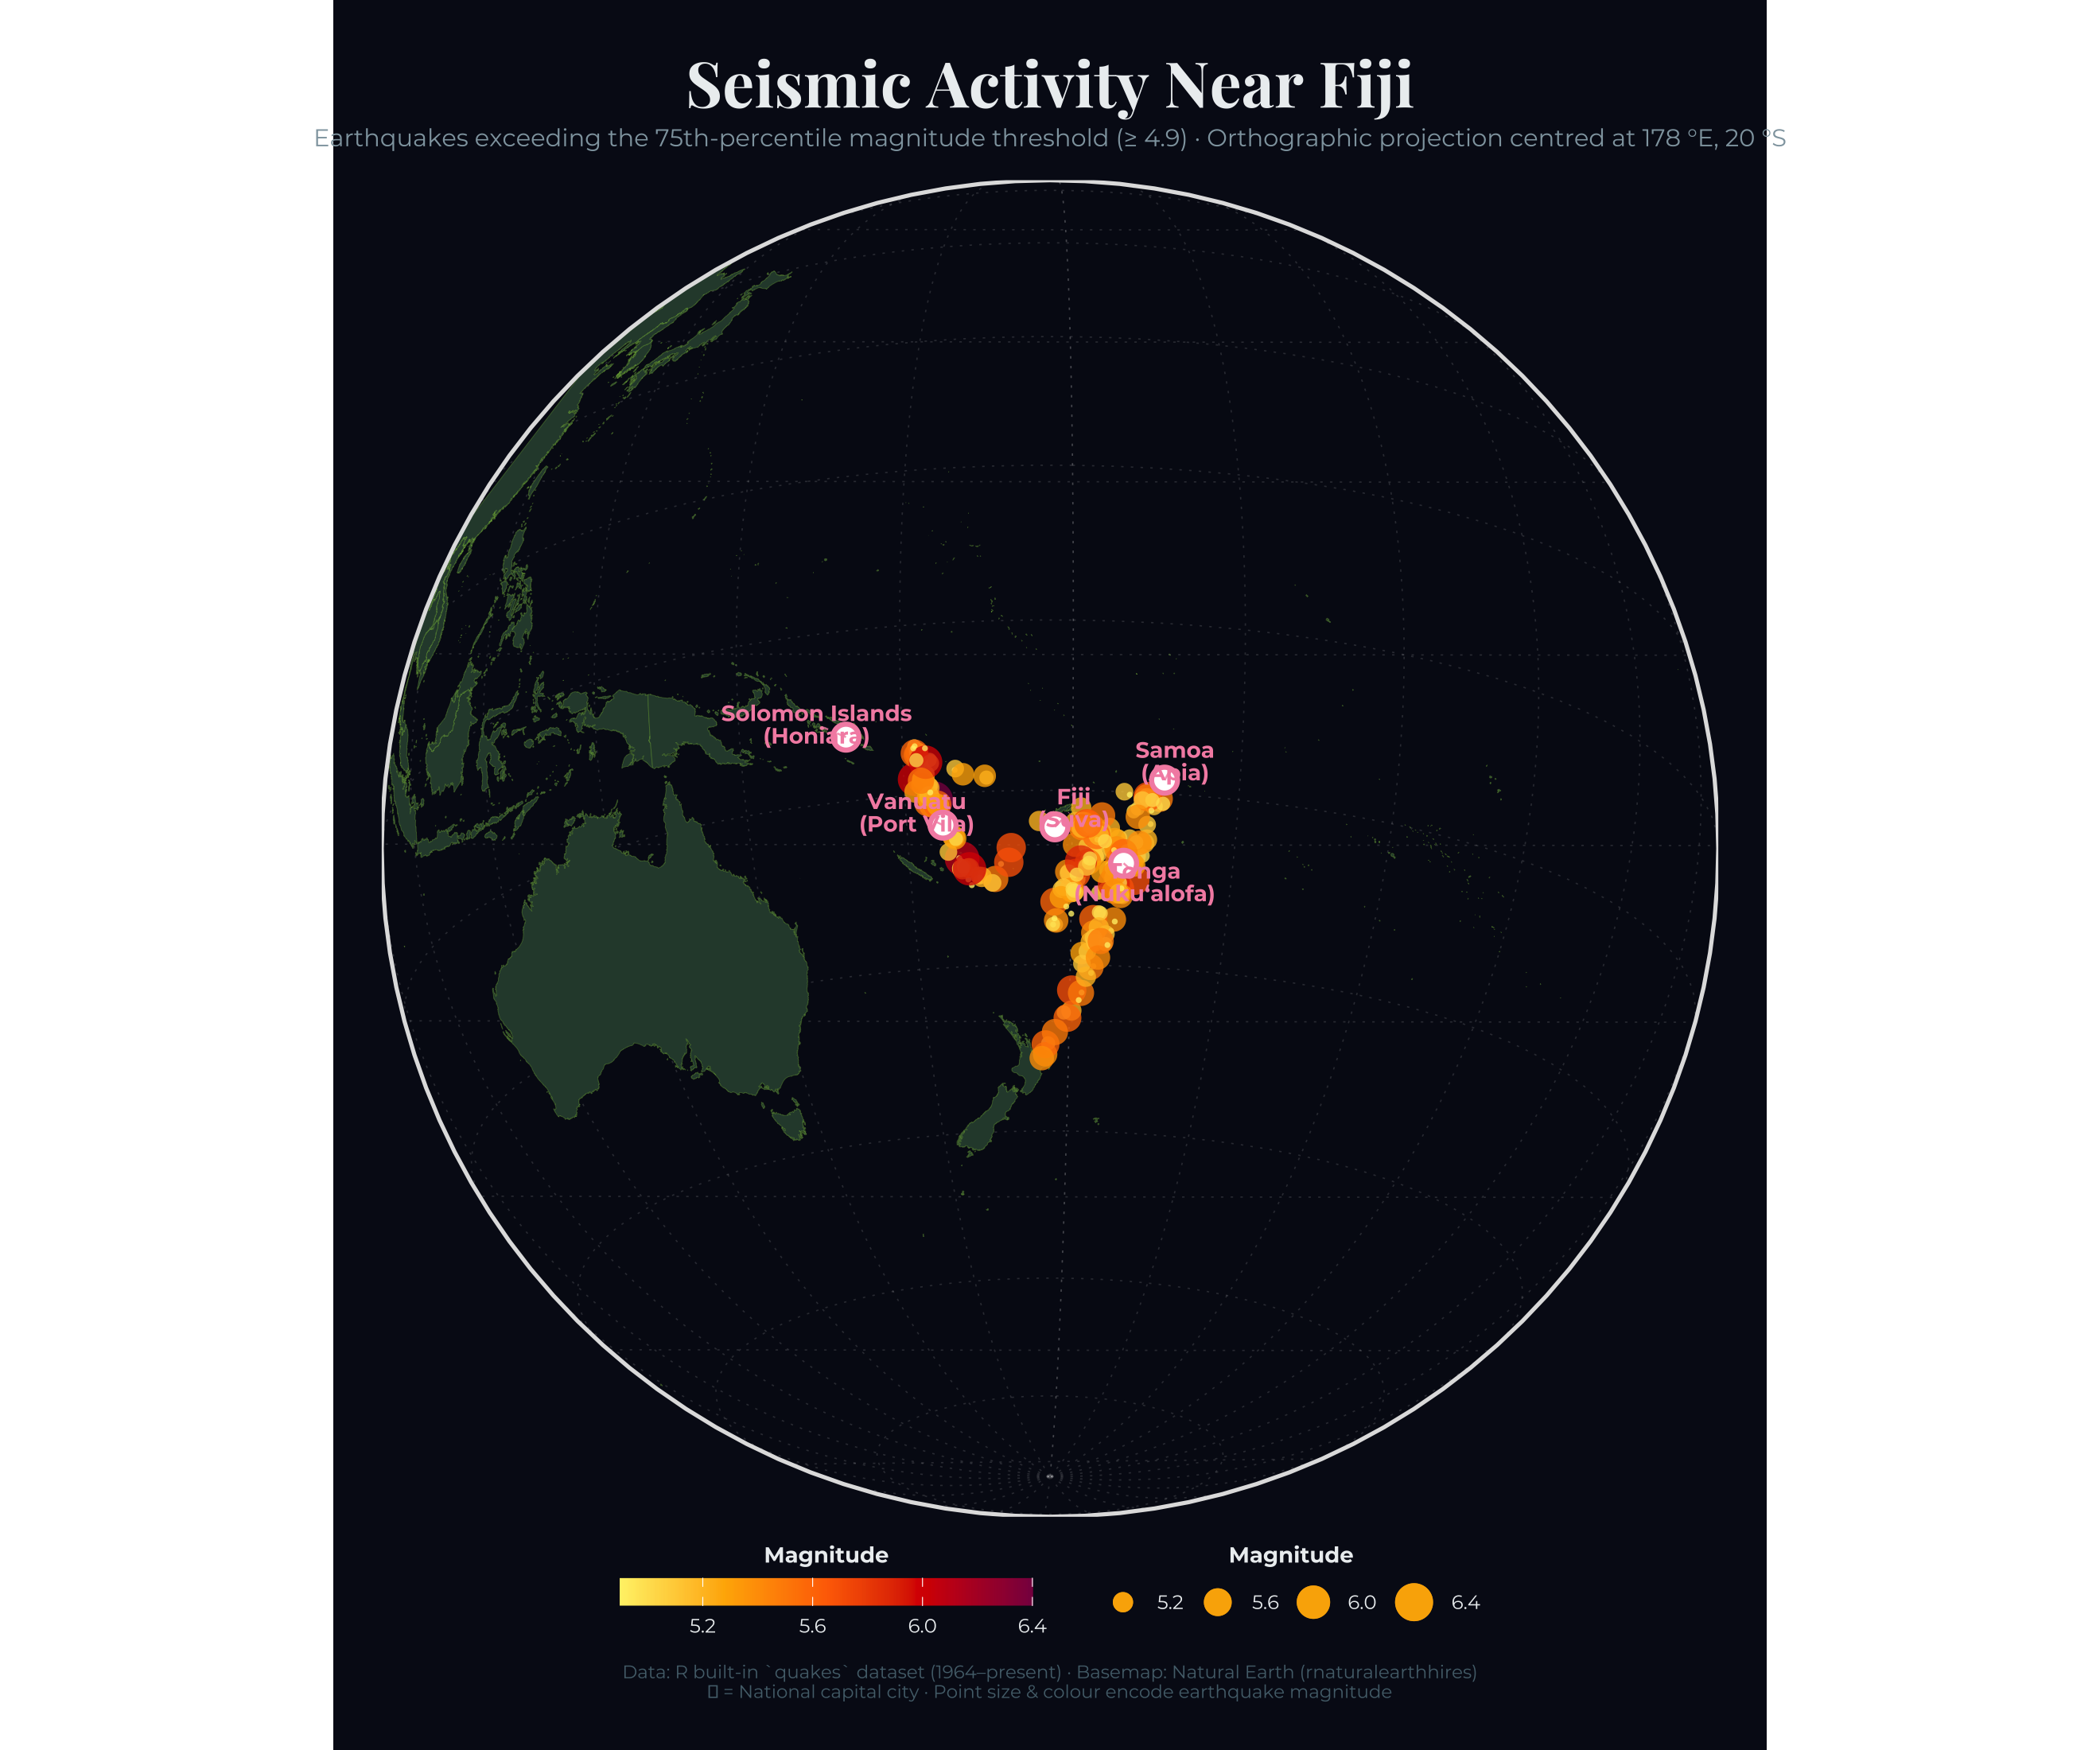

In [22]:
print(FijiEarthquakeMap)

I dont know about you, but I already love the map. We were able to capture that 3D globe effect. The only issues though, are the visibility of the data. There is no point making a highly aestheic, complex map if it cannot give us valuable information. The magnitudes are too clustered and it makes it difficult for anyone to point out which area on the map had the highest or lowest magnitude. 

To tackle that issue, we will make an interactive map/globe. The interactive map/globe will allow us to spin, zoom, and hover over points on this map.

See [Fiji Earthquakes — Interactive South Pacific Map in R]()